# Cable Source 2 — Cables Roboflow Dataset

Purpose:
Inspect a second independent source for the E-Safe cable_plug class.

This source is intended to provide complete consumer cables, charging cables, cords and wires with different backgrounds from TrashNet++.

Raw files must remain unchanged.

In [10]:
from pathlib import Path

def windows_long_path(path):
    path = Path(path).resolve()
    return "\\\\?\\" + str(path)

In [1]:
from pathlib import Path

dataset_path = Path(
    "../../data/item_images/raw/cables_roboflow"
)

print("Exists:", dataset_path.exists())

Exists: True


In [2]:
for path in dataset_path.rglob("*"):
    if path.is_dir():
        print(path)

..\..\data\item_images\raw\cables_roboflow\train
..\..\data\item_images\raw\cables_roboflow\train\images
..\..\data\item_images\raw\cables_roboflow\train\labels


In [3]:
from collections import Counter

extensions = Counter()

for file in dataset_path.rglob("*"):
    if file.is_file():
        extensions[file.suffix.lower()] += 1

print(extensions)

Counter({'.txt': 539, '.jpg': 537, '.yaml': 1})


In [4]:
yaml_files = list(dataset_path.rglob("*.yaml"))

print(yaml_files)

with open(yaml_files[0], "r") as f:
    print(f.read())

[WindowsPath('../../data/item_images/raw/cables_roboflow/data.yaml')]
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 4
names: ['Charging-cable', 'Cords', 'cable wire', 'wires']

roboflow:
  workspace: batteries-95xlo
  project: cables-9skjt
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/batteries-95xlo/cables-9skjt/dataset/1


In [5]:
for split in ["train", "valid", "test"]:

    image_dir = dataset_path / split / "images"
    label_dir = dataset_path / split / "labels"

    images = list(image_dir.glob("*")) if image_dir.exists() else []
    labels = list(label_dir.glob("*.txt")) if label_dir.exists() else []

    print(
        split,
        "| images:", len(images),
        "| labels:", len(labels)
    )

train | images: 538 | labels: 538
valid | images: 0 | labels: 0
test | images: 0 | labels: 0


In [6]:
image_dir = dataset_path / "train" / "images"
label_dir = dataset_path / "train" / "labels"

print("Files inside images folder:")
for file in image_dir.iterdir():
    if file.suffix.lower() not in {".jpg", ".jpeg", ".png", ".webp"}:
        print(file.name)

print("\nNon-label files / unusual TXT files:")
for file in label_dir.iterdir():
    if file.suffix.lower() != ".txt":
        print(file.name)

Files inside images folder:

Non-label files / unusual TXT files:


In [7]:
image_files = [
    f for f in image_dir.iterdir()
    if f.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}
]

label_files = list(label_dir.glob("*.txt"))

print("Real image files:", len(image_files))
print("TXT label files:", len(label_files))

Real image files: 538
TXT label files: 538


In [8]:
image_stems = {f.stem for f in image_files}
label_stems = {f.stem for f in label_files}

missing_labels = image_stems - label_stems
missing_images = label_stems - image_stems

print("Images without labels:", len(missing_labels))
print("Labels without images:", len(missing_images))

print("Missing labels:", list(missing_labels)[:10])
print("Missing images:", list(missing_images)[:10])

Images without labels: 0
Labels without images: 0
Missing labels: []
Missing images: []


In [11]:
from collections import Counter

class_names = {
    0: "Charging-cable",
    1: "Cords",
    2: "cable wire",
    3: "wires"
}

object_counts = Counter()
image_counts = Counter()

for label_file in label_files:

    classes_in_image = set()

    with open(windows_long_path(label_file), "r") as f:
        for line in f:

            values = line.strip().split()

            if not values:
                continue

            class_id = int(values[0])

            object_counts[class_id] += 1
            classes_in_image.add(class_id)

    for class_id in classes_in_image:
        image_counts[class_id] += 1

print("OBJECT COUNTS")

for class_id, name in class_names.items():
    print(name, object_counts[class_id])

print("\nIMAGE COUNTS")

for class_id, name in class_names.items():
    print(name, image_counts[class_id])

OBJECT COUNTS
Charging-cable 175
Cords 289
cable wire 46
wires 74

IMAGE COUNTS
Charging-cable 146
Cords 274
cable wire 46
wires 72


In [12]:
from PIL import Image
from collections import Counter

size_counts = Counter()

for image_path in image_files:
    with Image.open(windows_long_path(image_path)) as img:
        size_counts[img.size] += 1

print(size_counts)

Counter({(640, 640): 538})


In [13]:
corrupt_images = []

for image_path in image_files:
    try:
        with Image.open(windows_long_path(image_path)) as img:
            img.verify()
    except Exception:
        corrupt_images.append(image_path)

print("Corrupt images:", len(corrupt_images))

Corrupt images: 0


In [15]:
image_class_rows = []

for label_file in label_files:

    with open(windows_long_path(label_file), "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    class_ids = {int(line.split()[0]) for line in lines}

    if len(class_ids) == 1:
        class_id = list(class_ids)[0]

        image_class_rows.append({
            "file_name": label_file.stem + ".jpg",
            "class_id": class_id,
            "class_name": class_names[class_id]
        })


CLASS: Charging-cable


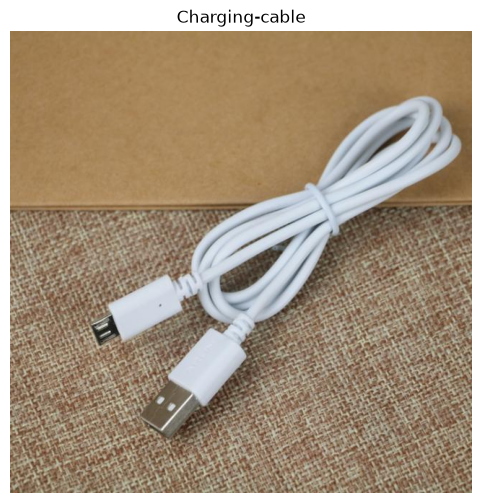

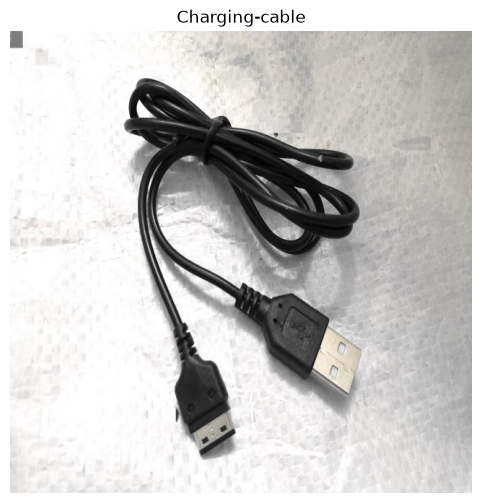

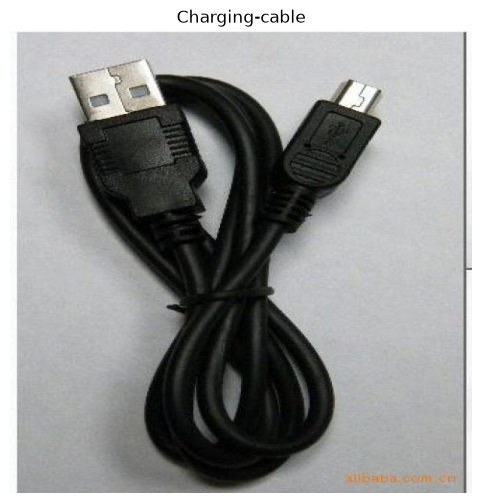

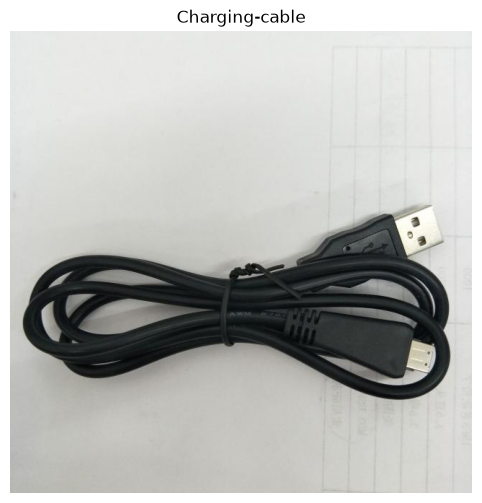

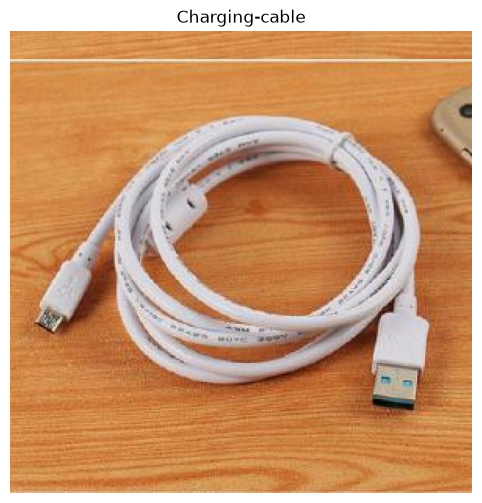

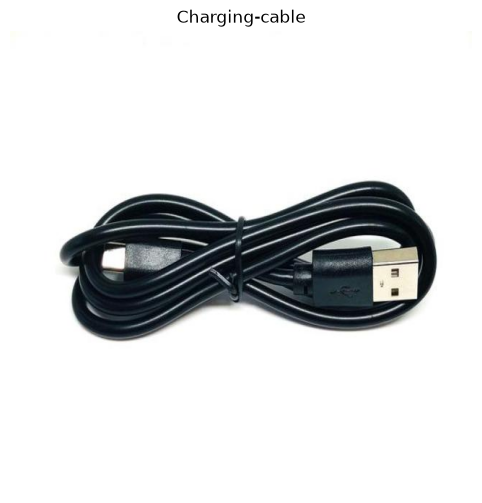


CLASS: Cords


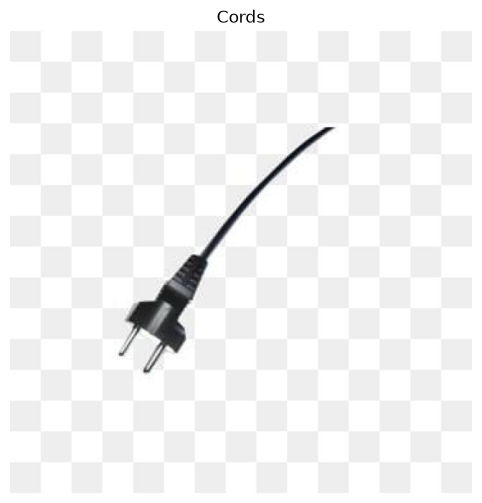

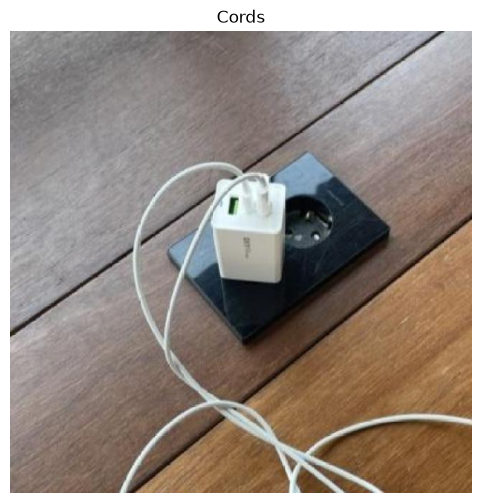

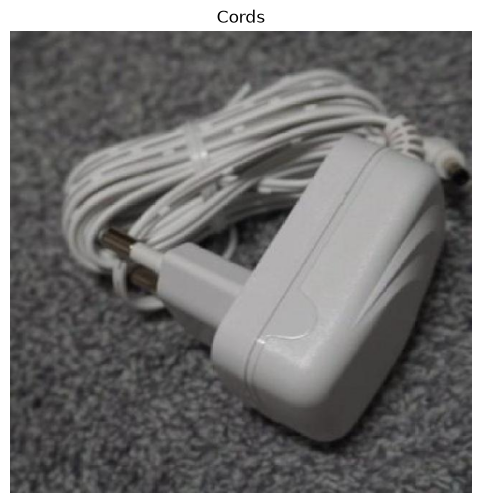

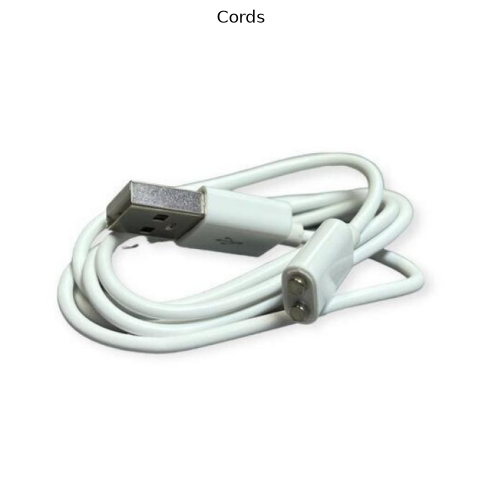

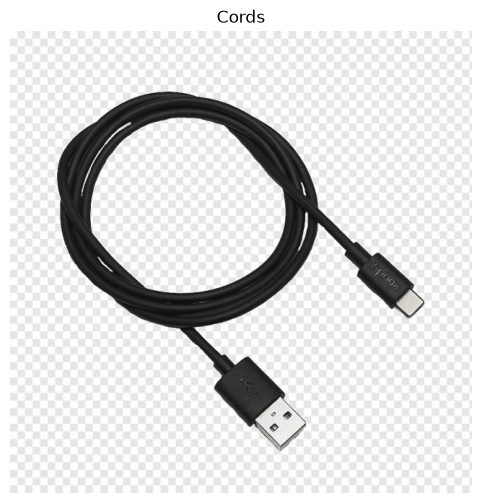

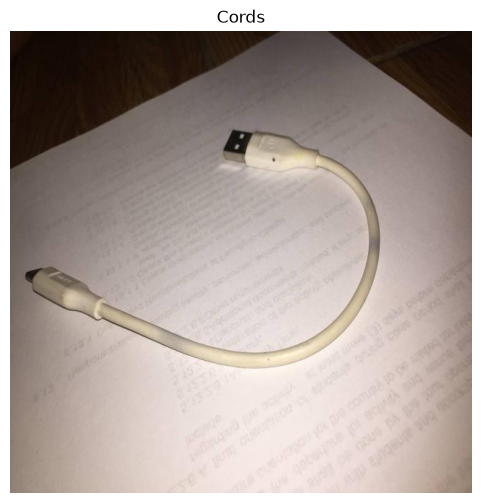


CLASS: cable wire


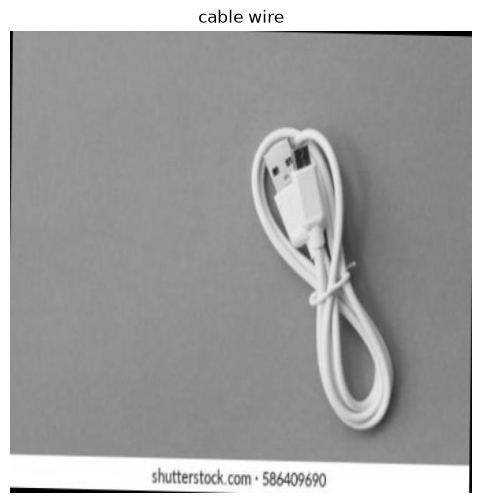

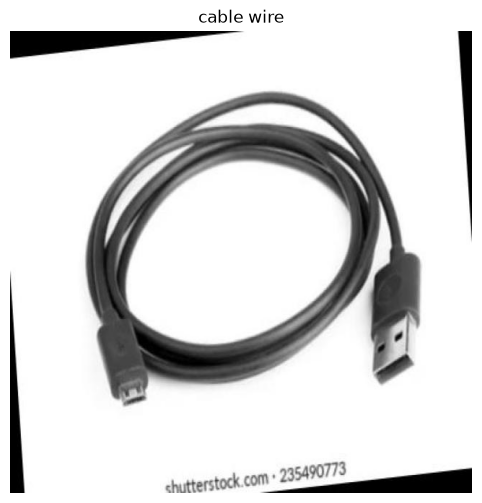

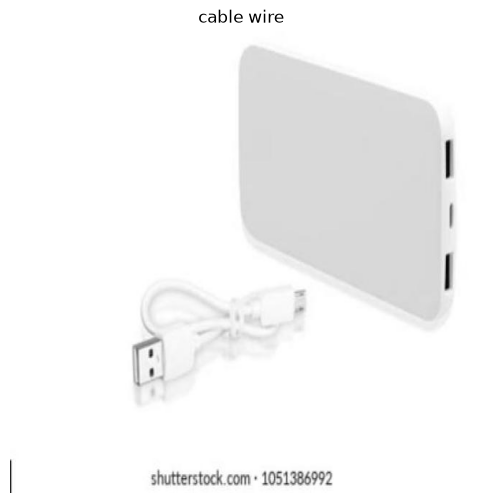

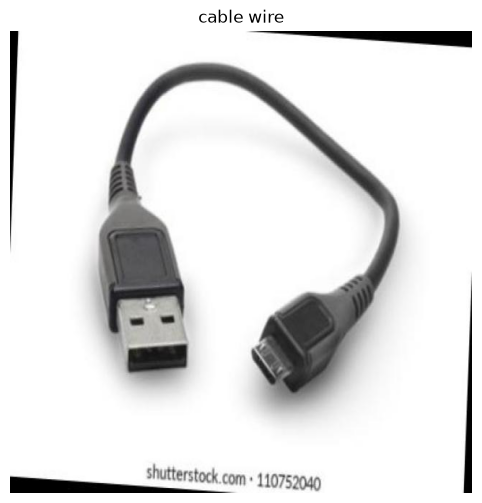

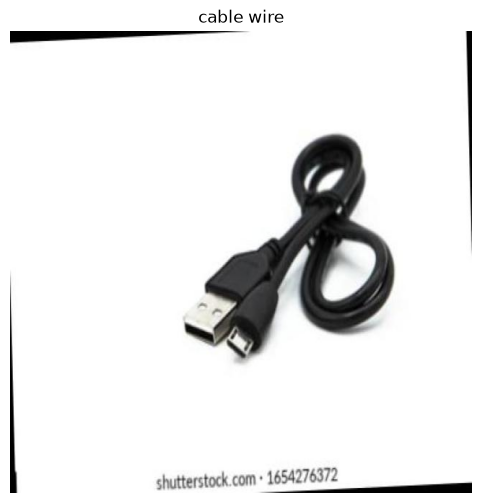

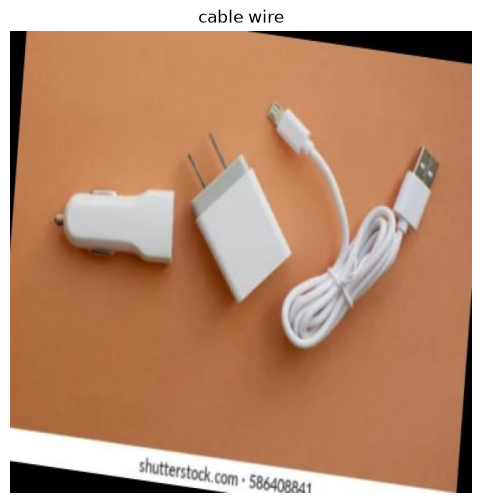


CLASS: wires


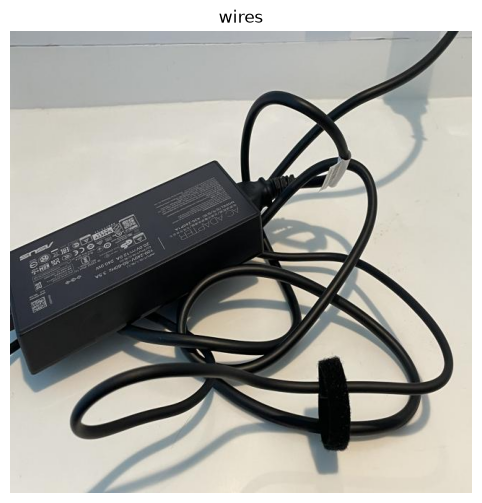

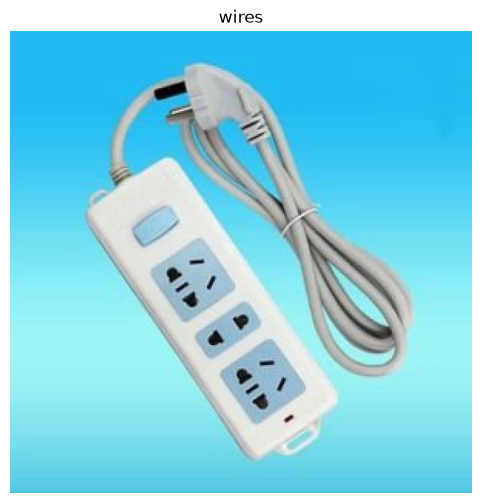

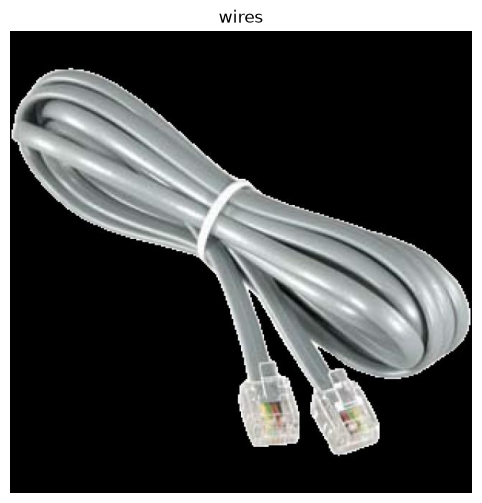

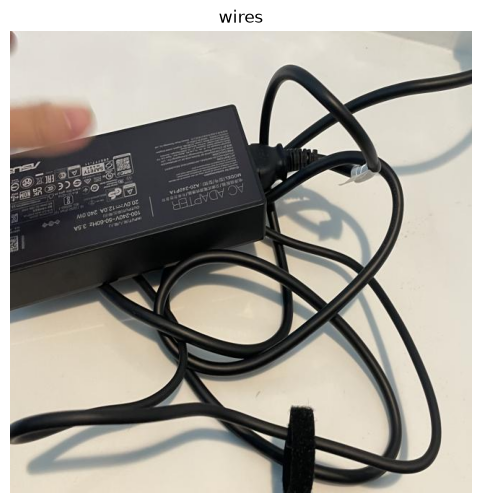

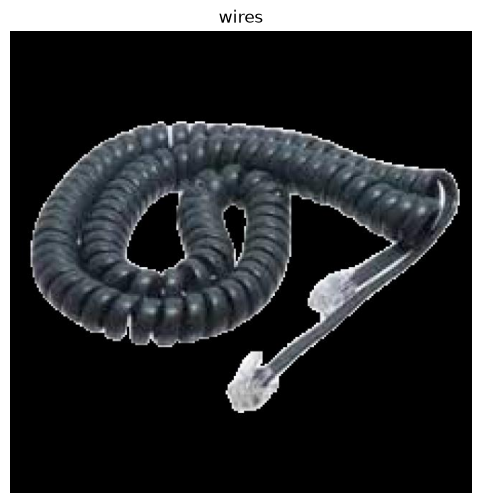

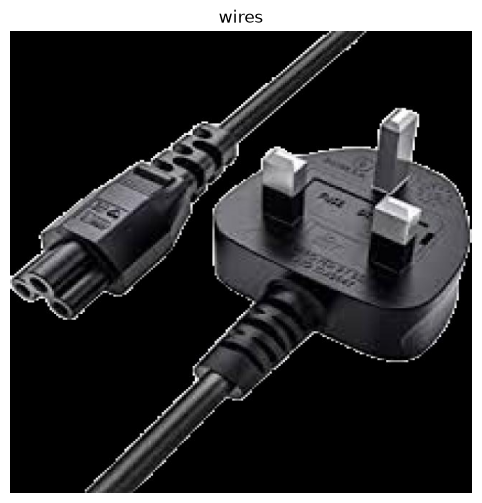

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import random

class_df = pd.DataFrame(image_class_rows)

for class_id, class_name in class_names.items():

    subset = class_df[class_df["class_id"] == class_id]

    samples = subset.sample(
        min(6, len(subset)),
        random_state=42
    )

    print(f"\nCLASS: {class_name}")

    for _, row in samples.iterrows():

        image_path = image_dir / row["file_name"]

        img = Image.open(windows_long_path(image_path))

        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")
        plt.show()

In [17]:
rows = []

for label_file in label_files:

    image_path = image_dir / f"{label_file.stem}.jpg"

    with open(windows_long_path(label_file), "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    bbox_ratios = []
    class_ids = []

    for line in lines:
        values = line.split()

        class_id = int(values[0])
        width = float(values[3])
        height = float(values[4])

        class_ids.append(class_id)
        bbox_ratios.append(width * height)

    rows.append({
        "file_name": image_path.name,
        "original_label": class_names[class_ids[0]],
        "object_count": len(lines),
        "largest_bbox_ratio": max(bbox_ratios)
    })

source2_df = pd.DataFrame(rows)

print(source2_df.shape)
print(source2_df["largest_bbox_ratio"].describe())
print(source2_df["object_count"].value_counts().sort_index())

(538, 4)
count    538.000000
mean       0.538097
std        0.242930
min        0.006067
25%        0.383907
50%        0.543021
75%        0.712627
max        1.000000
Name: largest_bbox_ratio, dtype: float64
object_count
1    507
2     20
3      8
4      2
5      1
Name: count, dtype: int64


In [18]:
import hashlib

hash_groups = {}

for image_path in image_files:

    with open(windows_long_path(image_path), "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()

    hash_groups.setdefault(file_hash, []).append(image_path.name)

exact_duplicates = [
    group
    for group in hash_groups.values()
    if len(group) > 1
]

print("Exact duplicate groups:", len(exact_duplicates))

for group in exact_duplicates[:10]:
    print(group)

Exact duplicate groups: 3
['IMG_4980-20230808-115645-_JPG.rf.724bfd3cfd43a11fabaa4341b9069e6c.jpg', 'IMG_4980-20230808-115645-_JPG.rf.93cc35181acb9817e91c43fcb58fa55b.jpg']
['IMG_4983-20230808-115717-_JPG.rf.0baa176490b3888ea1b3fd4eee143d0b.jpg', 'IMG_4983-20230808-115717-_JPG.rf.f5df931790cfb538c9ad6eb8d67ad23e.jpg']
['IMG_4984-20230808-115721-_JPG.rf.1ba5c5ab51d5a36979f5c7170608ba50.jpg', 'IMG_4984-20230808-115721-_JPG.rf.2d0af48942580fe2bfe226fe9a2b2c86.jpg']


In [19]:
import imagehash

image_hashes = []

for image_path in image_files:

    with Image.open(windows_long_path(image_path)) as img:
        phash = imagehash.phash(img)

    image_hashes.append(
        (image_path.name, phash)
    )

near_duplicates = []

for i in range(len(image_hashes)):
    for j in range(i + 1, len(image_hashes)):

        name1, hash1 = image_hashes[i]
        name2, hash2 = image_hashes[j]

        distance = hash1 - hash2

        if distance <= 4:
            near_duplicates.append(
                (name1, name2, distance)
            )

print("Near-duplicate pairs:", len(near_duplicates))

for pair in near_duplicates[:20]:
    print(pair)

Near-duplicate pairs: 12
('0ffd4aceca8a053c0d61ddcc4091c73d_jpg.rf.2e1641a7166acd041c7e6ae5801bc4d0.jpg', '8fa6adbb5e95a42e39603c50f9e3078c_jpg.rf.745eb53cfc1175c4ac231c3bfb5718d6.jpg', np.int64(2))
('20_png.rf.1f1c9b704cdbf9bae60903e94d8f31ba.jpg', '49_png.rf.808ce7e6cbe3d9e9ed05c14e4d474ff6.jpg', np.int64(0))
('32_jpg.rf.613917875f90e2a84286951c1936c8ce.jpg', '32_jpg.rf.e82abef3e38b39ccfe90d55909e9b538.jpg', np.int64(2))
('38_png.rf.16d08d0a88a2271dc50ef0eba5dbd410.jpg', '43_png.rf.01a86c90bf82a0f867f4b3ec6dd087e5.jpg', np.int64(2))
('3903-000985-1_1_webp.rf.8ba0a502f8bacbd5b63a522efa6fc6a8.jpg', '488076421_670874045429983_5809146727809068842_n_jpg.rf.4cc3d7ca30d0fb676c93080b32459229.jpg', np.int64(0))
('3903-001117-1_1_webp.rf.d49b5d547dc252db4ee03d91415d7ac8.jpg', '489035766_2073912223110047_5512283509739670674_n_jpg.rf.bcc36b1a141d1aac1586a55c913381e0.jpg', np.int64(0))
('482874698_4861920610613814_7018612676075801406_n-1-_jpg.rf.4a4cd5cb939111f0b2190330e0be5d0b.jpg', '488933160_6

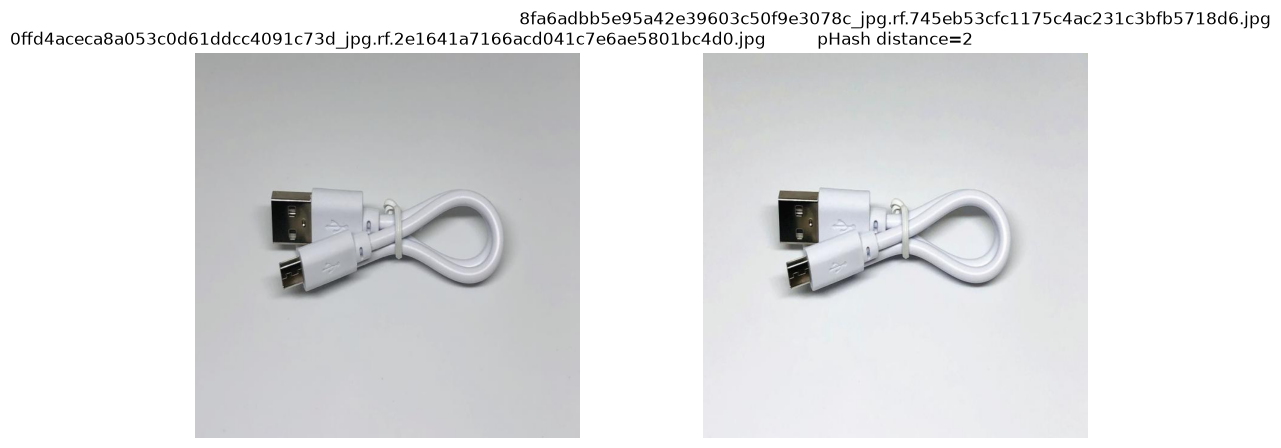

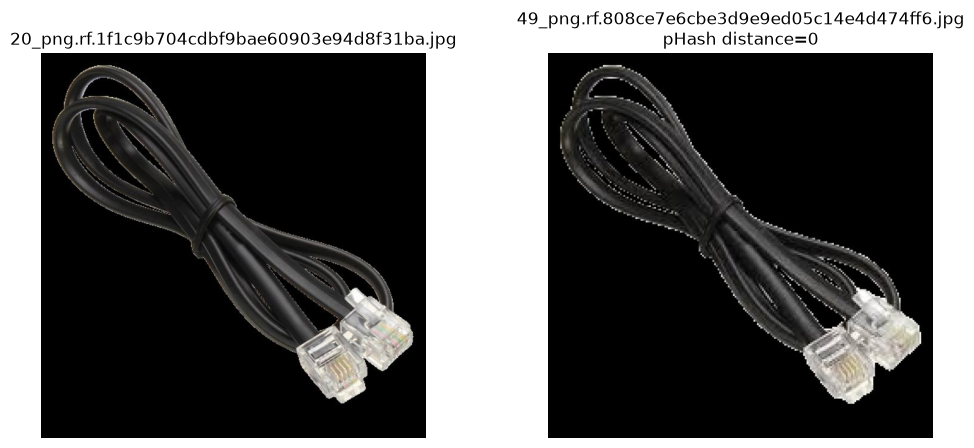

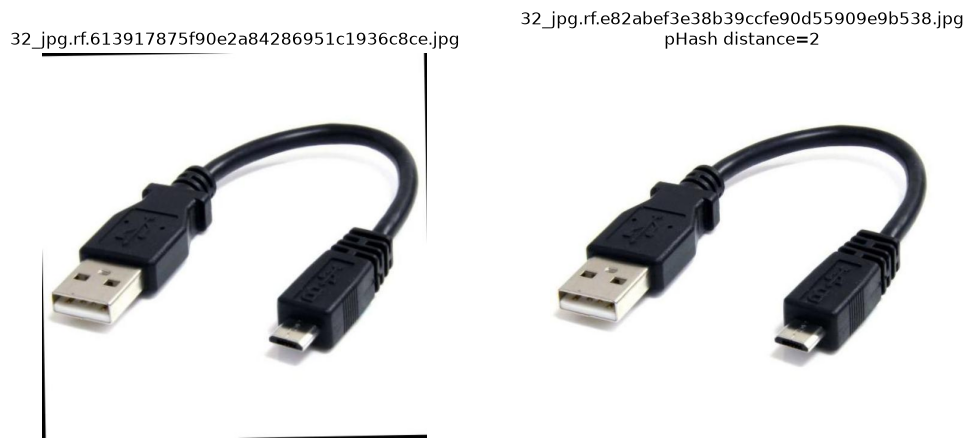

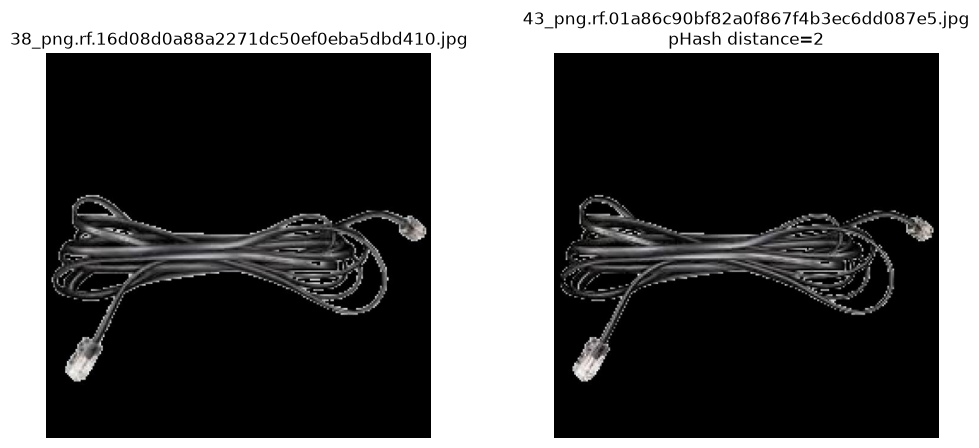

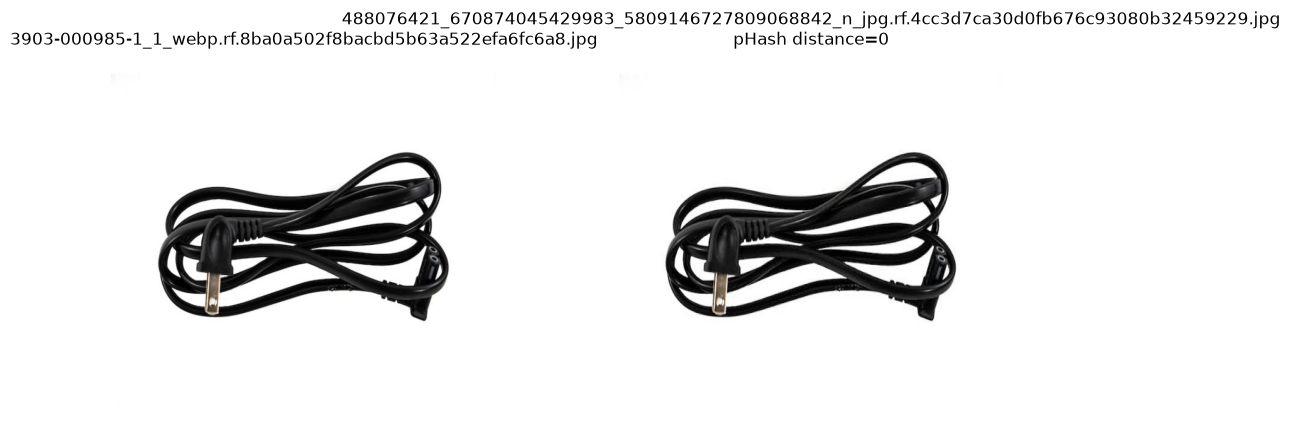

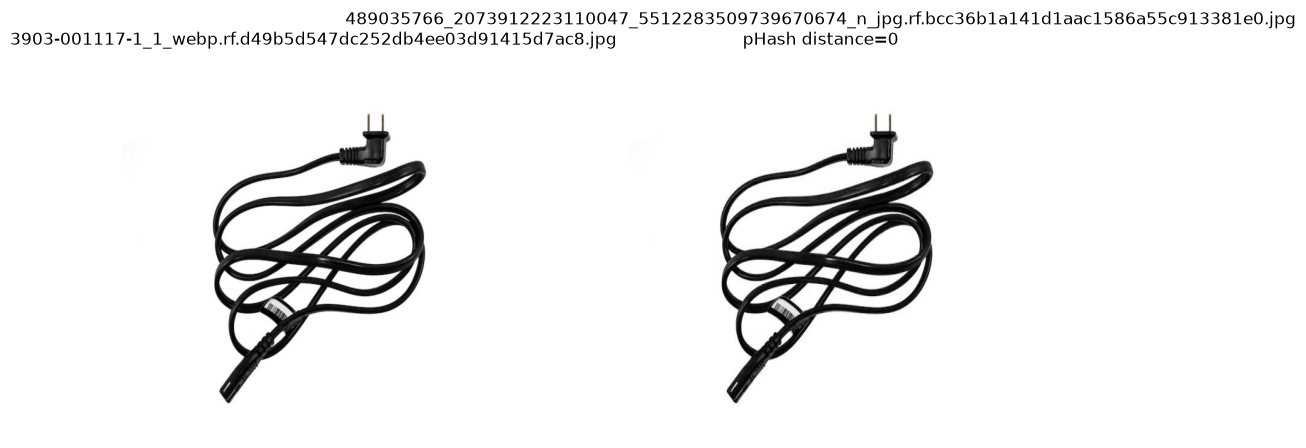

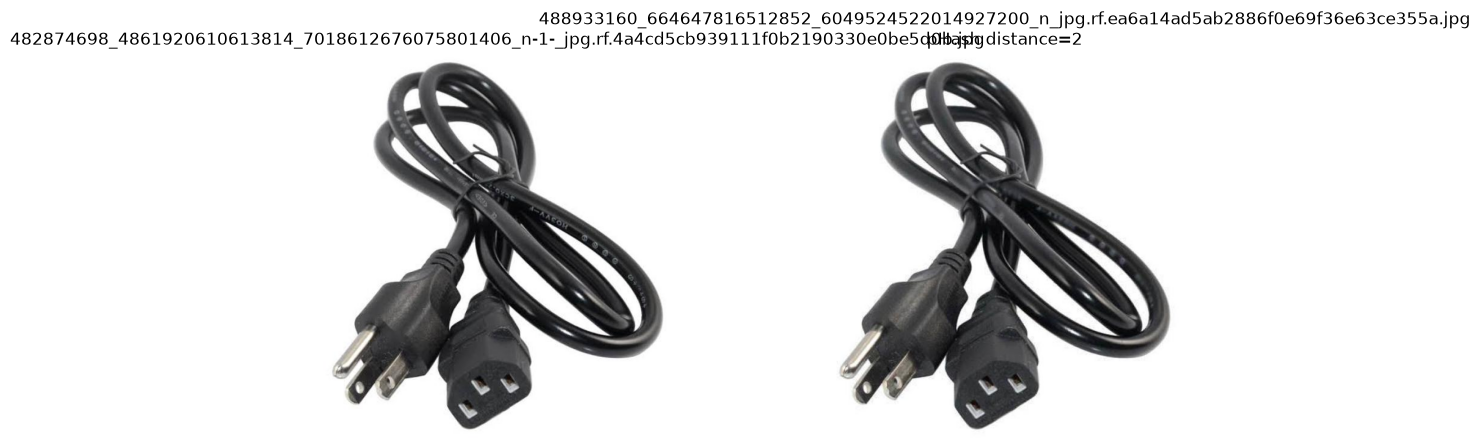

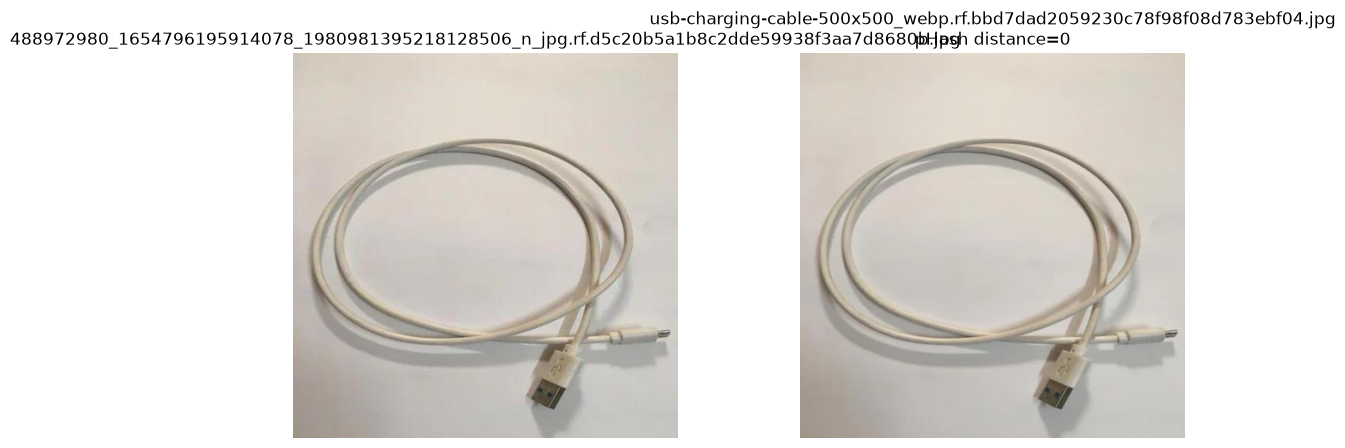

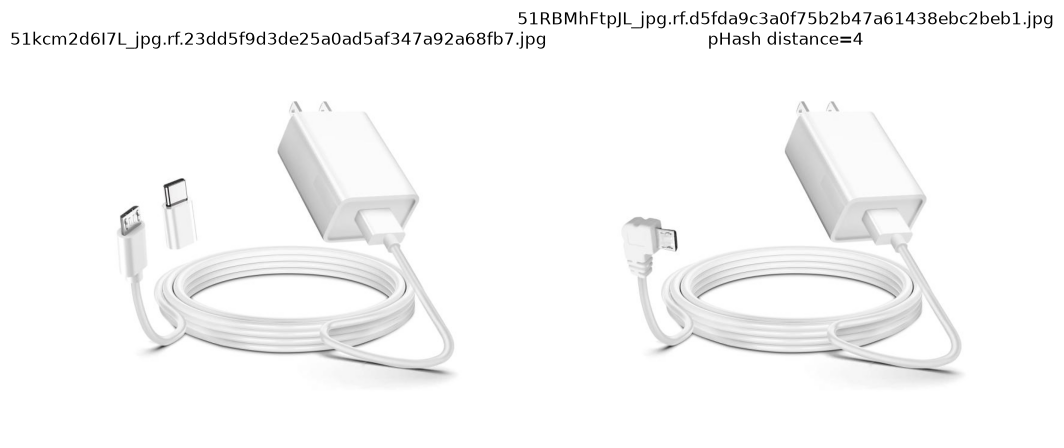

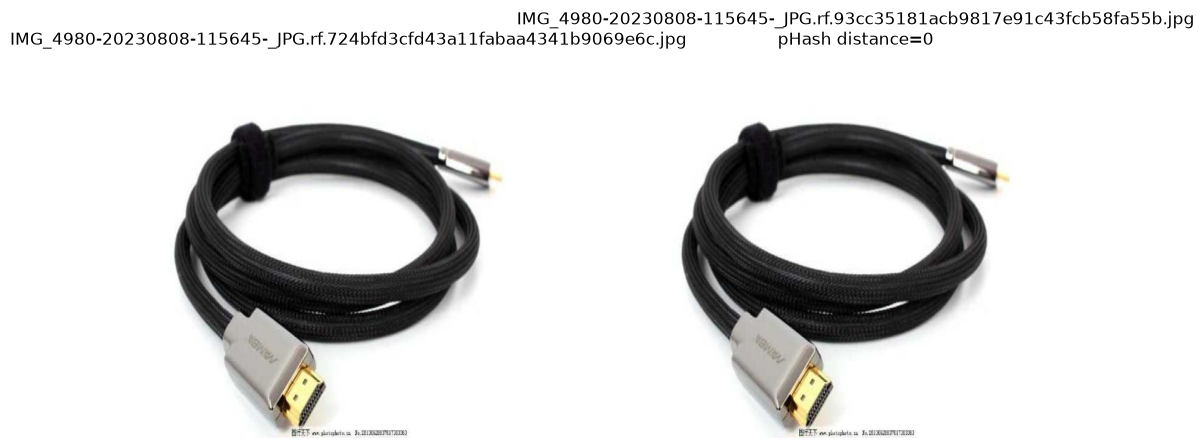

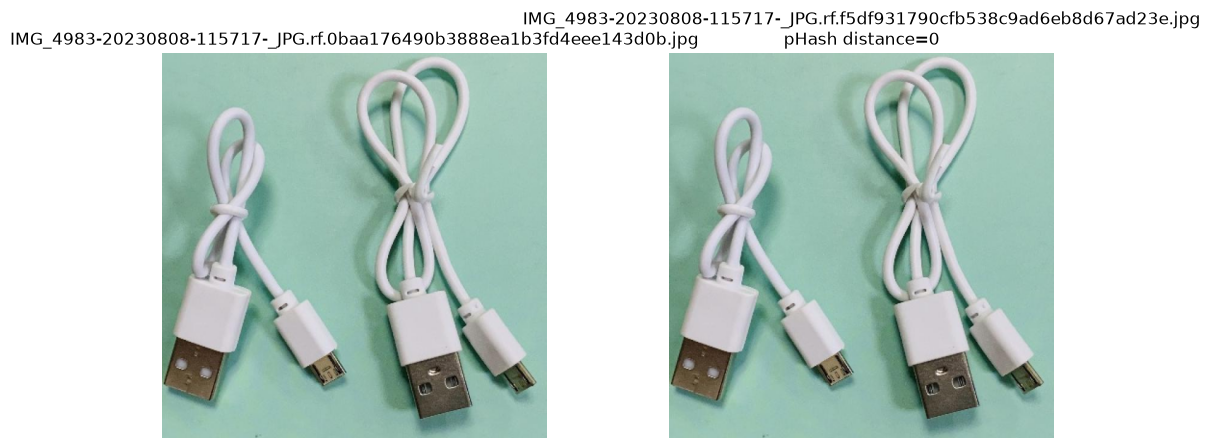

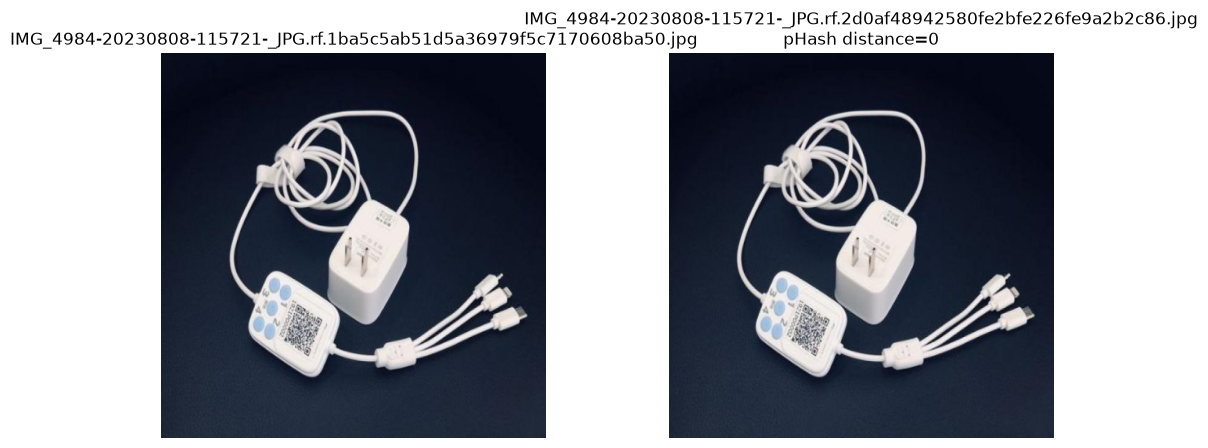

In [20]:
import matplotlib.pyplot as plt
from PIL import Image

for name1, name2, distance in near_duplicates:

    path1 = image_dir / name1
    path2 = image_dir / name2

    img1 = Image.open(windows_long_path(path1))
    img2 = Image.open(windows_long_path(path2))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(img1)
    axes[0].set_title(name1)
    axes[0].axis("off")

    axes[1].imshow(img2)
    axes[1].set_title(
        f"{name2}\npHash distance={distance}"
    )
    axes[1].axis("off")

    plt.show()

In [21]:
print(size_counts)

Counter({(640, 640): 538})


In [22]:
print("Corrupt images:", len(corrupt_images))

Corrupt images: 0


In [23]:
parent = {}

def find(x):
    if x not in parent:
        parent[x] = x
    if parent[x] != x:
        parent[x] = find(parent[x])
    return parent[x]

def union(a, b):
    root_a = find(a)
    root_b = find(b)

    if root_a != root_b:
        parent[root_b] = root_a


# All 12 visually verified pairs are duplicates
for name1, name2, distance in near_duplicates:
    union(name1, name2)


groups = {}

for name in parent:
    root = find(name)
    groups.setdefault(root, []).append(name)


duplicate_groups = [
    sorted(group)
    for group in groups.values()
    if len(group) > 1
]

duplicate_groups = sorted(
    duplicate_groups,
    key=lambda x: x[0]
)

duplicate_map = {}

for i, group in enumerate(duplicate_groups, start=1):

    group_id = f"DUP{i:02d}"

    for file_name in group:
        duplicate_map[file_name] = group_id


print("Duplicate groups:", len(duplicate_groups))
print("Images belonging to duplicate groups:", len(duplicate_map))

for i, group in enumerate(duplicate_groups, start=1):
    print(f"DUP{i:02d}:", group)

Duplicate groups: 12
Images belonging to duplicate groups: 24
DUP01: ['0ffd4aceca8a053c0d61ddcc4091c73d_jpg.rf.2e1641a7166acd041c7e6ae5801bc4d0.jpg', '8fa6adbb5e95a42e39603c50f9e3078c_jpg.rf.745eb53cfc1175c4ac231c3bfb5718d6.jpg']
DUP02: ['20_png.rf.1f1c9b704cdbf9bae60903e94d8f31ba.jpg', '49_png.rf.808ce7e6cbe3d9e9ed05c14e4d474ff6.jpg']
DUP03: ['32_jpg.rf.613917875f90e2a84286951c1936c8ce.jpg', '32_jpg.rf.e82abef3e38b39ccfe90d55909e9b538.jpg']
DUP04: ['38_png.rf.16d08d0a88a2271dc50ef0eba5dbd410.jpg', '43_png.rf.01a86c90bf82a0f867f4b3ec6dd087e5.jpg']
DUP05: ['3903-000985-1_1_webp.rf.8ba0a502f8bacbd5b63a522efa6fc6a8.jpg', '488076421_670874045429983_5809146727809068842_n_jpg.rf.4cc3d7ca30d0fb676c93080b32459229.jpg']
DUP06: ['3903-001117-1_1_webp.rf.d49b5d547dc252db4ee03d91415d7ac8.jpg', '489035766_2073912223110047_5512283509739670674_n_jpg.rf.bcc36b1a141d1aac1586a55c913381e0.jpg']
DUP07: ['482874698_4861920610613814_7018612676075801406_n-1-_jpg.rf.4a4cd5cb939111f0b2190330e0be5d0b.jpg', '488

In [24]:
manifest_df = source2_df.copy()

manifest_df["source_dataset"] = "Cables Roboflow v1"
manifest_df["original_split"] = "train"
manifest_df["esafe_label"] = "cable_plug"

manifest_df["duplicate_group"] = (
    manifest_df["file_name"]
    .map(duplicate_map)
    .fillna("")
)

manifest_df["selection_status"] = "REVIEW"

manifest_df = manifest_df[
    [
        "file_name",
        "source_dataset",
        "original_split",
        "original_label",
        "esafe_label",
        "object_count",
        "largest_bbox_ratio",
        "duplicate_group",
        "selection_status"
    ]
]

print(manifest_df.shape)
manifest_df.head()

(538, 9)


,file_name,source_dataset,original_split,original_label,esafe_label,object_count,largest_bbox_ratio,duplicate_group,selection_status
0,-_20230808173632_1_jpg.rf.accf9ac70ca142e38de5...,Cables Roboflow v1,train,wires,cable_plug,1,0.928125,,REVIEW
1,-_20230808173635_1_jpg.rf.6dd01c0c7c4de7275418...,Cables Roboflow v1,train,wires,cable_plug,1,0.776563,,REVIEW
2,-_20230808173636_jpg.rf.bc9914320d3cd446b68fe0...,Cables Roboflow v1,train,wires,cable_plug,1,0.859951,,REVIEW
3,-_20230808173637_1_jpg.rf.ea650df5330861db63b4...,Cables Roboflow v1,train,wires,cable_plug,1,0.803906,,REVIEW
4,-_20230808173637_jpg.rf.4724f281f7c69e8d8d38b1...,Cables Roboflow v1,train,wires,cable_plug,1,0.928906,,REVIEW


In [25]:
print(
    manifest_df["duplicate_group"]
    .replace("", pd.NA)
    .dropna()
    .value_counts()
    .sort_index()
)

print(
    "Images marked as duplicates:",
    (manifest_df["duplicate_group"] != "").sum()
)

duplicate_group
DUP01    2
DUP02    2
DUP03    2
DUP04    2
DUP05    2
DUP06    2
DUP07    2
DUP08    2
DUP09    2
DUP10    2
DUP11    2
DUP12    2
Name: count, dtype: int64
Images marked as duplicates: 24


In [26]:
output_path = "../../data/metadata/cables_roboflow_manifest.csv"

manifest_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

Saved: ../../data/metadata/cables_roboflow_manifest.csv


In [27]:
check_df = pd.read_csv(output_path)

print(check_df.shape)
check_df.head()

(538, 9)


,file_name,source_dataset,original_split,original_label,esafe_label,object_count,largest_bbox_ratio,duplicate_group,selection_status
0,-_20230808173632_1_jpg.rf.accf9ac70ca142e38de5...,Cables Roboflow v1,train,wires,cable_plug,1,0.928125,NaN,REVIEW
1,-_20230808173635_1_jpg.rf.6dd01c0c7c4de7275418...,Cables Roboflow v1,train,wires,cable_plug,1,0.776563,NaN,REVIEW
2,-_20230808173636_jpg.rf.bc9914320d3cd446b68fe0...,Cables Roboflow v1,train,wires,cable_plug,1,0.859951,NaN,REVIEW
3,-_20230808173637_1_jpg.rf.ea650df5330861db63b4...,Cables Roboflow v1,train,wires,cable_plug,1,0.803906,NaN,REVIEW
4,-_20230808173637_jpg.rf.4724f281f7c69e8d8d38b1...,Cables Roboflow v1,train,wires,cable_plug,1,0.928906,NaN,REVIEW


# EDA Conclusions — Cables Roboflow v1 → `cable_plug`

## Dataset Structure

- Source: Roboflow Universe — Cables dataset.
- Dataset version: 1.
- Licence: CC BY 4.0.
- The downloaded dataset contains four original classes:
  - `Charging-cable`
  - `Cords`
  - `cable wire`
  - `wires`
- All four source classes are relevant to the E-Safe Dataset A class `cable_plug`.
- The dataset contains 538 images and 538 corresponding YOLO annotation files.
- All 538 images are present in the source `train` split.
- No usable validation or test split was included in the downloaded export.
- E-Safe will therefore create its own train/validation/test split later after combining all cable sources.

## Class Distribution

Image counts:

- Charging-cable: 146 images
- Cords: 274 images
- cable wire: 46 images
- wires: 72 images

Object counts:

- Charging-cable: 175 objects
- Cords: 289 objects
- cable wire: 46 objects
- wires: 74 objects

All 538 images belong to one of the four relevant cable categories.

## Image Quality

- All 538 images are 640 × 640 pixels.
- No corrupt images were detected.
- No images were missing annotation files.
- No annotation files were missing their corresponding images.

## Scene and Appearance Observations

Manual visual inspection showed that:

- The complete cable or cord is visible in most sampled images.
- The cable is generally the main object in the image.
- Many cables are coiled or tied in the typical way that charging or laptop cables are stored.
- White backgrounds are common, although black, brown and other backgrounds are also present.
- Most sampled images appear to be product-style photographs.
- A smaller number appear to be more natural/real-world photographs.
- Plugs/connectors are often visible as part of the complete cable.
- Compared with TrashNet++, this source contains cleaner and more object-focused cable photographs.

This creates a useful complementary source:
- TrashNet++ contributes cluttered and more realistic waste-scene images.
- Cables Roboflow contributes clearer, larger and more complete cable/cord examples.

## Object Prominence

Largest bounding-box area ratio statistics:

- Mean: 0.5381 (~53.81%)
- Median: 0.5430 (~54.30%)
- 25th percentile: 0.3839 (~38.39%)
- 75th percentile: 0.7126 (~71.26%)
- Minimum: 0.0061 (~0.61%)
- Maximum: 1.0000 (100%)

Therefore, the cable occupies a relatively large portion of most images.

Object-count distribution:

- 507 images contain 1 annotated object
- 20 images contain 2 objects
- 8 images contain 3 objects
- 2 images contain 4 objects
- 1 image contains 5 objects

Approximately 94% of the images therefore contain only one annotated object.

## Duplicate Analysis

- 3 exact duplicate groups were detected using file-content hashing.
- Perceptual hashing detected 12 duplicate/near-duplicate pairs in total.
- All 12 pairs were manually inspected and confirmed to represent duplicate or effectively identical images.
- These form 12 duplicate groups containing 24 images in total.
- Duplicate groups are recorded in the manifest as `DUP01` to `DUP12`.
- Raw images will not be deleted.
- During final cleaning, one representative from each duplicate group can be retained.
- If exactly one image per duplicate group is retained, approximately 526 images remain before further quality filtering.

## Main Limitations

- Product-style photography is dominant.
- White backgrounds occur frequently.
- Many cables are neatly coiled/tied.
- This appearance distribution may not fully represent dirty, tangled, partially visible or discarded cables encountered in real e-waste environments.
- Therefore, this source should not be used as the only source for `cable_plug`.

# Future Work / Preprocessing Decisions — Cables Roboflow Source

- Keep the downloaded raw dataset unchanged.
- Map all four original classes (`Charging-cable`, `Cords`, `cable wire`, `wires`) to the E-Safe Dataset A label `cable_plug`.
- Preserve the original Roboflow labels in metadata for traceability.
- Use the `duplicate_group` field to prevent duplicate images from leaking across future train/validation/test splits.
- During final cleaning, retain only one representative from each confirmed duplicate group.
- Do not use the original Roboflow `train` designation as the final E-Safe training split.
- Create E-Safe's own split only after all `cable_plug` sources have been combined and cleaned.
- Review unusually tiny-object images manually rather than applying a fixed bounding-box threshold.
- Do not automatically crop every image because most images already contain a prominent complete cable.
- Cropping may be considered only for individual images where excessive irrelevant background reduces usefulness.
- Preserve whole-cable context wherever possible, especially cable ends, plugs and connectors.
- This source should complement rather than replace TrashNet++, because its dominant product-photo and coiled-cable appearance creates a different dataset bias.
- A further plug/connector-focused source may be added later to strengthen the `plug` portion of the combined `cable_plug` class.
- Dataset A is for item recognition only. Visible cable hazards such as exposed conductors, cut insulation or burn damage belong to Dataset B and should not be labelled as hazards here.
- Resize and pretrained-model normalization will be performed only after the final Dataset A sources are merged and the candidate classification models are chosen.
- Perform augmentation only on the final training split.
- Keep the separate real-world phone-photo Dataset C for domain-shift evaluation.

In [28]:
import pandas as pd

trashnet = pd.read_csv(
    "../../data/metadata/trashnet_cable_manifest.csv"
)

roboflow = pd.read_csv(
    "../../data/metadata/cables_roboflow_manifest.csv"
)

# Prefix duplicate IDs so DUP01 from one dataset
# cannot be confused with DUP01 from the other.
def prefix_dup(value, prefix):
    if pd.isna(value) or str(value).strip() == "":
        return ""
    return f"{prefix}_{value}"

trashnet["duplicate_group"] = trashnet["duplicate_group"].apply(
    lambda x: prefix_dup(x, "TN")
)

roboflow["duplicate_group"] = roboflow["duplicate_group"].apply(
    lambda x: prefix_dup(x, "RF")
)

trashnet["source_manifest"] = "trashnet_cable_manifest.csv"
roboflow["source_manifest"] = "cables_roboflow_manifest.csv"

common_cols = [
    "file_name",
    "source_dataset",
    "original_split",
    "original_label",
    "esafe_label",
    "duplicate_group",
    "selection_status",
    "source_manifest"
]

combined = pd.concat(
    [
        trashnet[common_cols],
        roboflow[common_cols]
    ],
    ignore_index=True
)

print(combined.shape)
print(combined["source_dataset"].value_counts())

combined.to_csv(
    "../../data/metadata/cable_plug_combined_manifest.csv",
    index=False
)

(1207, 8)
source_dataset
TrashNet++ jCDBig     669
Cables Roboflow v1    538
Name: count, dtype: int64


# Final Status — Dataset A `cable_plug`

Data collection for the `cable_plug` class is complete.

Two complementary sources were collected and inspected:

1. TrashNet++ jCDBig
   - 669 cable candidate images
   - contributes more cluttered and realistic scenes
   - duplicate groups and source limitations have been documented

2. Cables Roboflow v1
   - 538 cable/cord images
   - contributes complete cables, charging cables, power cords and visible plugs/connectors
   - mostly object-focused/product-style images
   - duplicate groups and source limitations have been documented

Total candidate images before final preprocessing: 1,207.

No additional cable or plug source is currently required.

The raw datasets will remain unchanged. Final merging, cross-source duplicate checking, duplicate removal, ambiguous-image review, class balancing and train/validation/test splitting will be performed later during the Dataset A preprocessing stage.

All relevant source labels will ultimately map to the E-Safe class `cable_plug`.

Visible hazard labels such as damaged insulation, exposed conductors or burn damage are not part of Dataset A and will be handled separately in Dataset B.